# **Neural Networks and Differential Equations: From Infinite Layers to Continuous Modelling**

## **Part II: Physics-Informed Neural Networks**

### **Tutorial @ IJCAI 2026**

#### **Cecília Coelho, Luís Ferrás and Andrzej Dulny**

#### **Go to [website][Website]**

[Website]: https://ceciliacoelho.github.io/tutorialNN4DEs

## Implementing PINNs for Forward Problems

Heat conduction, the process by which thermal energy moves through materials, is fundamental to countless systems, from everyday objects like cooking pans to advanced technologies like microprocessor cooling. In steady-state scenarios (where temperature no longer changes over time), this process is governed by the Laplace equation, a special case of the Poisson equation where there is no internal heat generation.

Consider a flat 2D metal plate and a steady-state scenario, where temperature is not changing over time. The heat distribution satisfies the Poisson's equation:

$$\nabla^2 u =\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
= 0,
\quad (x, y) \in \Omega
$$

where $\nabla^2 u = 0$ implies that heat flows smoothly through the plate, balancing out temperature differences.

Our goal is to train a neural network $\hat{u}(x, y; \boldsymbol{\theta})$ to approximate the true solution $u(x, y; \boldsymbol{\theta})$ while strictly satisfying the equation above. To achieve this, we design the loss function with two key components:

$$ {L}(\boldsymbol{\theta}) \mathrm{MSE}_u
+\mathrm{MSE}_{\mathrm{PDE}}
$$

where

$$\mathrm{MSE}_{\mathrm{PDE}}
\frac{1}{N_{\mathrm{PDE}}}
\sum_{n=1}^{N_{\mathrm{PDE}}}
\left(
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
\right)^2
$$

enforces the equation across the entire domain for all $N_{\mathrm{PDE}}$ data points.


Let us consider the steady-state heat conduction problem posed and walk through how each mathematical element of the PINN (domain, differential operator, loss function, and neural network) is translated into *Python* code using the *DeepXDE* library with a *PyTorch* backend.

The implementation is very straightforward and follows the mathematical structure of the problem almost line-for-line, with the geometry, physics, boundary conditions, and the network all defined separately. The step-by-step implementation is as follows:

1. **Importing the necessary libraries:** First, we import four libraries that this implementation relies on:

   * `numpy` provides array operations needed for evaluating boundary conditions or the analytical solution outside of the network's computational graph.
   * `deepxde` is the official PINNs library providing specific functions.
   * `torch` is the backend we will be using in this book for implementing neural networks.
   * `matplotlib` provides the visualisation of the results.


In [ ]:
!pip install deepxde

import os
os.environ["DDE_BACKEND"] = "pytorch"   # force the PyTorch backend

import numpy as np
import deepxde as dde
import torch
import matplotlib.pyplot as plt

2. **Defining the geometry:** A PINN needs to know where the governing equation must be enforced. In our example, $\Omega$ is a flat square plate, which can be declared directly as:
geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])

This line allows us to sample collocation points ${(x_n,y_n)}{n=1}^{N{\mathrm{PDE}}}$ from the interior of the domain $\Omega$, and to sample points along $\partial \Omega$ for the boundary conditions. These points are randomly sampled and do not form a fixed structured grid, which is one of the defining differences between PINNs and classical numerical solvers.

In [ ]:
geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])

3. **Encoding the governing equations:** The equation states that the Laplacian of $u$ must vanish everywhere in $\Omega$. When coding, this becomes a function that takes as input the coordinates x and the network output u, and returns the residual of the PDE:

In [ ]:
def pde(x, u):
    du_xx = dde.grad.hessian(u, x, i=0, j=0)   # d^2u/dx^2
    du_yy = dde.grad.hessian(u, x, i=1, j=1)   # d^2u/dy^2
    return du_xx + du_yy

Since this is a pedagogical exercise and we have access to the closed-form solution. We define it to evaluate the performance of the PINN.

In [ ]:
def u_exact(x):
    return np.sin(np.pi * x[:, 0:1]) * np.sinh(np.pi * x[:, 1:2]) / np.sinh(np.pi)

Here, dde.grad.hessian calls PyTorch's automatic differentiation twice in succession on the network's output, thus resulting in the exact derivative of the network function $\hat{u}(x,y;\boldsymbol{\theta})$. This allows the PINN to enforce the differential equation pointwise, at any coordinate, without discretising the space.

In [ ]:
    def boundary_left(x, on_boundary):
        return on_boundary and np.isclose(x[0], 0.0)

    bc_left = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_left)

    def boundary_right(x, on_boundary):
        return on_boundary and np.isclose(x[0], 1.0)

    bc_right = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_right)

    def boundary_bottom(x, on_boundary):
        return on_boundary and np.isclose(x[1], 0.0)

    bc_bottom = dde.icbc.DirichletBC(geom, lambda x: 0.0, boundary_bottom)

    def boundary_top(x, on_boundary):
        return on_boundary and np.isclose(x[1], 1.0)

    bc_top = dde.icbc.DirichletBC(geom, lambda x: np.sin(np.pi * x[:, 0:1]), boundary_top)

    bcs = [bc_left, bc_right, bc_bottom, bc_top]

4. **Encoding the boundary conditions:** The $\mathrm{MSE}_{u}$ term in the loss function requires labelled data on the boundary. Each edge of the plate is described by: (i) a predicate that identifies which points of $\Omega$ lie on that edge, and (ii) the prescribed value of $u$ there. This is implemented for all four edges as follows:

5. **Putting together the loss function:** To define the loss function, we use `dde.data.PDE`, which takes the previously defined components (geometry, PDE residual, and the list of boundary conditions) and internally builds the two terms of the loss:


Here, `num_domain` corresponds to $N_{\mathrm{PDE}}$. Note that `solution=u_exact` is not part of the training loss, as the network never sees the true solution during the optimisation process. This is included to report a relative error between the prediction and the known analytical solution, which is useful for practice exercises, as analytical solutions for real problems are usually not available.


In [ ]:
data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=2000,     # N_PDE collocation points -> MSE_PDE
    num_boundary=400,    # boundary points -> MSE_u
    num_test=1000,
    solution=u_exact,    # optional: only used to report training error
    )

6. **Building the neural network:** Here, we use a standard fully connected feed-forward neural network; however, other options are available (refer to [Lu et al. (2021)](https://doi.org/10.1016/j.cma.2021.113168)). It has two input neurons to accommodate the two spatial coordinates $(x,y)$ and produces a single scalar output $\hat{u}$, represented by the single-neuron output layer. For expressiveness, we add four hidden layers with 50 neurons each:

We opt for $\tanh$ activation functions because $\hat{u}$ must be twice differentiable for `dde.grad.hessian` to produce a meaningful second derivative.


In [ ]:
layer_sizes = [2] + [50] * 4 + [1]
net = dde.nn.FNN(layer_sizes, "tanh", "Glorot uniform")

7. **Combining everything and training:** The `data` object, encompassing the physics and the boundary conditions, and the `net` object, the trainable solution approximation, are combined into a single model with `dde.Model`:


In [ ]:
model = dde.Model(data, net)

Then, the optimiser and the evaluation metric are chosen (this metric is not part of the loss function and does not affect the optimisation process). The model is trained for 10,000 iterations, followed by an optional fine-tuning of $\boldsymbol{\theta}$ using a different optimiser:


The double-training approach, Adam followed by L-BFGS, is standard practice in the PINN literature. Adam's stochastic updates are effective at making fast early progress across a complex, non-convex loss landscape. L-BFGS uses quasi-Newton updates, which excel at the fine-grained convergence needed to drive the PDE residual close to machine precision once the network is already in the right neighbourhood of the parameter space.


In [ ]:
model.compile("adam", lr=1e-3, metrics=["l2 relative error"])
model.train(iterations=10000)

model.compile("L-BFGS")
model.train()

Compiling model...
'compile' took 0.043247 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7bee6110e200>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110e200>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110dd00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110dd00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110ef20>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110ef20>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110e660>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee6110e660>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                            Test loss                                             Test metric   
0         [2.57e-02, 5.80e-04, 1.90e-01, 7.80e-02, 3.12e-01]    [2.41e-02, 5.80e-04, 1.90e-01, 7.80e-02, 3.12e-01]    [9.84e-01]    
1000      [8.34e-03, 1.23e-02, 1.42e-02, 3.96e-03, 4.04e-02]    [4.68e-03, 1.23e-02, 1.42e-02, 3.96e-03, 4.04e-02]    [3.05e-01]    
2000      [5.38e-03, 4.42e-03, 6.47e-03, 9.15e-04, 1.61e-02]    [3.36e-03, 4.42e-03, 6.47e-03, 9.15e-04, 1.61e-02]   

(<deepxde.model.LossHistory at 0x7bee611577a0>,
 <deepxde.model.TrainState at 0x7bee61157920>)

9. **Visualising the results:** Since in this example we know the analytical solution,

$$
u(x,y) = \sin(\pi x)\frac{\sinh(\pi y)}{\sinh(\pi)},
$$

it is possible to compute the true error and visually compare the PINN's prediction with the analytical solution. Thus, we evaluate $\hat{u}(x,y;\boldsymbol{\theta}^*)$ on a dense regular grid and compute the error:


In [ ]:
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)
XY = np.vstack((X.flatten(), Y.flatten())).T

u_pred = model.predict(XY).reshape(ny, nx)
u_true = u_exact(XY).reshape(ny, nx)
error = np.abs(u_pred - u_true)

l2_error = np.linalg.norm(u_pred - u_true) / np.linalg.norm(u_true)
print(f"Relative L2 error: {l2_error:.4e}")

Relative L2 error: 3.0681e-03


In order to visualise the predictions and errors, we make three plots showing the PINN's prediction, the ground-truth analytical solution, and their absolute difference. This is an effective way to present PINN results, as it allows visual confirmation of where the network agrees with the true physics and where, if anywhere, it struggles.


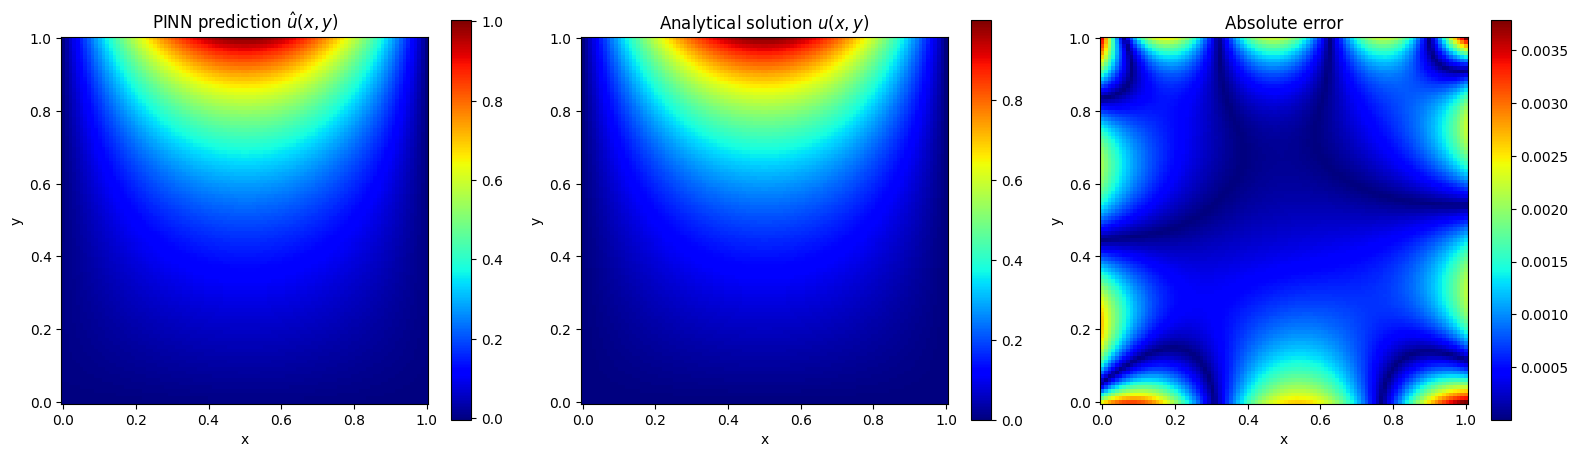

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axs[0].pcolormesh(X, Y, u_pred, shading="auto", cmap="jet")
axs[0].set_title("PINN prediction $\\hat{u}(x,y)$")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].pcolormesh(X, Y, u_true, shading="auto", cmap="jet")
axs[1].set_title("Analytical solution $u(x,y)$")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].pcolormesh(X, Y, error, shading="auto", cmap="jet")
axs[2].set_title("Absolute error")
fig.colorbar(im2, ax=axs[2])

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### Exercises

1. Consider the problem in the Example and its walkthrough implementation.

   a. Verify that if `pde(x,u)` returns exactly zero, then $\hat{u}$ satisfies Laplace's equation exactly at that point.

   b. What would change in the implementation if the plate had an internal heat source, *i.e.*, if we were solving the full Poisson equation $\nabla^2 u = f(x,y)$ instead of Laplace's equation?

   c. What happens to the PDE residual and to the quality of the solution if the $\tanh$ activation function is replaced by a rectified linear unit (ReLU)?



2. Consider the results in the Figure, in which the trained PINN's prediction, the analytical solution, and the absolute error are compared over the plate. The error is high near the two bottom corners of the domain, forming ring-like contours visible in the rightmost panel.

   1. Retrain the model after increasing the boundary points `num_boundary` from 400 to 800, keeping all other settings fixed. Regenerate the Figure and compare the new error panel to the original. Does the error near the bottom corners decrease at the same rate as the overall relative $L_2$ error, or is one affected more than the other?

   b. Modify the boundary sampling so that additional training points are added near the two bottom corners. This can be done by passing a small set of extra points via the `anchors` argument of `dde.data.PDE`:

```python id="5l5x3a"
corner_pts = np.vstack([
    np.column_stack((np.linspace(0, 0.05, 20), np.zeros(20))),
    np.column_stack((np.linspace(0.95, 1.0, 20), np.zeros(20))),
])

data = dde.data.PDE(
    geom,
    pde,
    bcs,
    num_domain=2000,
    num_boundary=400,
    num_test=1000,
    solution=u_exact,
    anchors=corner_pts,
)
```


  Retrain the model with these anchor points included. Does adding points near the corners reduce the corner error more efficiently than the uniform increase in (a)?



In [ ]:
# Write your code here

3. DeepXDE provides a built-in callback `dde.callbacks.PDEPointResampler` that periodically resamples the collocation points during training:

```python id="r6u3yw"
resampler = dde.callbacks.PDEPointResampler(period=1000)
model.train(iterations=10000, callbacks=[resampler])
```


  Retrain the model with this strategy. Does it have any measurable effect on the corner error? Why would resampling collocation points be expected, or not expected, to reduce an error that is concentrated on the boundary?



In [ ]:
# Write your code here

## Implementing PINNs for Inverse Problems

Consider the two-dimensional heat equation with an unknown thermal diffusivity parameter $\alpha$:

$$\frac{\partial u}{\partial t}
\alpha
\left(
\frac{\partial^2 u}{\partial x^2}
+
\frac{\partial^2 u}{\partial y^2}
\right)
= 0,
\qquad
(t,x,y)\in(0,T]\times\Omega.
$$

In this problem, the value $\alpha$ must be identified from the available observations of the temperature field $u(t,x,y)$.

Suppose we have two types of information:

* **Observed solution data:** ${(t_n,x_n,y_n,u_n)}*{n=1}^{N_{\mathrm{observed}}}$;
* **Boundary and/or initial condition data:** ${(t_m,x_m,y_m,u_m)}*{m=1}^{N_{\mathrm{BC/IC}}}$.

The solution is approximated by a neural network $\hat{u}(t,x,y;\boldsymbol{\theta})$, and $\alpha$ is defined as an additional trainable variable. The inverse problem can be written as:

$$\frac{\partial \hat{u}}{\partial t}(t,x,y;\boldsymbol{\theta})
\alpha
\left[
\frac{\partial^2 \hat{u}}{\partial x^2}(t,x,y;\boldsymbol{\theta})
+
\frac{\partial^2 \hat{u}}{\partial y^2}(t,x,y;\boldsymbol{\theta})
\right]
= 0,
\qquad
(t,x,y)\in(0,T]\times\Omega.
$$

where

$$
\mathrm{MSE}_{u}
\mathrm{MSE}_{\mathrm{observed}}
+
\mathrm{MSE}_{\mathrm{BC/IC}},
$$

with

$$
\mathrm{MSE}_{\mathrm{observed}}
\frac{1}{N_{\mathrm{observed}}}
\sum_{n=1}^{N_{\mathrm{observed}}}
\left(
\hat{u}(t_n,x_n,y_n;\boldsymbol{\theta})
u_n
\right)^2
$$

and

$$
\mathrm{MSE}_{\mathrm{BC/IC}}
\frac{1}{N_{\mathrm{BC/IC}}}
\sum_{m=1}^{N_{\mathrm{BC/IC}}}
\left(
\hat{u}(t_m,x_m,y_m;\boldsymbol{\theta})
u_m
\right)^2.
$$

Rewriting this as an unconstrained problem gives:

$$
\min_{\boldsymbol{\theta},\alpha}
\quad
\mathrm{MSE}_{u}
+
\mu,\mathrm{MSE}_{\mathrm{PDE}},
\tag{1}
$$

where

$$
\mathrm{MSE}_{\mathrm{PDE}}
\frac{1}{N_{\mathrm{PDE}}}
\sum_{k=1}^{N_{\mathrm{PDE}}}
\left(
\frac{\partial \hat{u}}{\partial t}(t_k,x_k,y_k;\boldsymbol{\theta})
\alpha
\left[
\frac{\partial^2 \hat{u}}{\partial x^2}(t_k,x_k,y_k;\boldsymbol{\theta})
+
\frac{\partial^2 \hat{u}}{\partial y^2}(t_k,x_k,y_k;\boldsymbol{\theta})
\right]
\right)^2.
$$

During training, the network parameters $\boldsymbol{\theta}$ and the diffusivity coefficient $\alpha$ are optimised simultaneously.


1. **Importing the necessary libraries:** As previously, we rely on the same libraries `numpy`, `deepxde`, `torch`, and `matplotlib`.



In [ ]:
import numpy as np
import deepxde as dde
import torch
import matplotlib.pyplot as plt

2. **Defining the space-time domain:** Unlike the steady-state forward problem, in this case $u$ evolves in time, so the domain must combine the spatial plate $\Omega$ with a time interval $[0,T]$. DeepXDE handles this through `GeometryXTime`, which combines a spatial geometry and a `TimeDomain` into a single space-time domain.



In [ ]:
geom = dde.geometry.Rectangle(xmin=[0, 0], xmax=[1, 1])
timedomain = dde.geometry.TimeDomain(0, 1)
geomtime = dde.geometry.GeometryXTime(geom, timedomain)

The points sampled from `geomtime` have three columns $(x,y,t)$ representing the spatial coordinates followed by time, a convention used to write the PDE residual.

3. **Declaring the unknown parameter:** The new ingredient of the inverse problem is that $\alpha$ is not a fixed number given to the model but instead an additional quantity to be learnt jointly with $\boldsymbol{\theta}$. To represent this with DeepXDE, we use `dde.Variable` initialised with an initial guess.



In [ ]:
alpha = dde.Variable(0.5)

At this stage, `alpha` is just an initial guess, and it will only approximate the true diffusivity when it is included in both the PDE residual and the optimiser's list of parameters.

4. **Encoding the governing equation:** The residual now involves $\alpha$ directly. Using the $(x,y,t)$ column convention, the time derivative is the Jacobian with respect to column $2$, while the spatial second derivatives are Hessians with respect to columns $0$ and $1$.

Note that, since $\alpha$ is a trainable variable, every time this residual is evaluated during training it uses the network's *current* estimate of the diffusivity, so the PDE loss carries information on $\alpha$ into its gradient.




In [ ]:
def pde(x, u):
  du_t = dde.grad.jacobian(u, x, i=0, j=2)   # du/dt
  du_xx = dde.grad.hessian(u, x, i=0, j=0)   # d^2u/dx^2
  du_yy = dde.grad.hessian(u, x, i=1, j=1)   # d^2u/dy^2
  return du_t - alpha * (du_xx + du_yy)

5. **Encoding the boundary and initial conditions:** We consider $u=0$ on all four edges of the plate and prescribe the initial temperature profile given by

$$
u(0,x,y)=\sin(\pi x)\sin(\pi y).
$$

These will be used to compute $\mathrm{MSE}_{\mathrm{BC/IC}}$.



In [ ]:
def boundary(x, on_boundary):
      return on_boundary

bc = dde.icbc.DirichletBC(geomtime, lambda x: 0.0, boundary)

def init_func(x):
    return np.sin(np.pi * x[:, 0:1]) * np.sin(np.pi * x[:, 1:2])

ic = dde.icbc.IC(geomtime, init_func, lambda _, on_initial: on_initial)

6. **Generating the observed data:** This is the second new ingredient that will be used for $\mathrm{MSE}_{\mathrm{observed}}$.

Note that, in a real application, these would be sensor readings or experimental measurements that would be loaded from a data file, typically saved as one row per measurement and columns for the time, spatial coordinates, and recorded temperature, for example:

|      $t$ |      $x$ |      $y$ |      $u$ |
| -------: | -------: | -------: | -------: |
|     0.00 |     0.31 |     0.62 |    0.812 |
|     0.00 |     0.55 |     0.18 |    0.294 |
|     0.05 |     0.31 |     0.62 |    0.774 |
| $\vdots$ | $\vdots$ | $\vdots$ | $\vdots$ |

Given a file `observed_data.csv` in this format, the data can be loaded and split into inputs and target values using `numpy`.

However, since we are solving an example problem, we will generate this observed data by using the known closed-form solution

$$
u(t,x,y)
e^{-2\pi^2\alpha_{\mathrm{true}}t}
\sin(\pi x)\sin(\pi y)
$$

for a chosen true diffusivity $\alpha_{\mathrm{true}}$. We generate synthetic observations by sampling scattered points in the space-time domain and evaluating this solution at them.

`PointSetBC` behaves like the Dirichlet boundary conditions except that, in this case, the boundary is simply the fixed set of $(x,y,t)$ locations where a measurement is available anywhere in the space-time domain. Note that $\alpha_{\mathrm{true}}$ is used only to generate the synthetic data and is not used during training.



In [ ]:
alpha_true = 0.4

def u_exact(x):
    xx, yy, t = x[:, 0:1], x[:, 1:2], x[:, 2:3]
    return np.exp(-2 * np.pi**2 * alpha_true * t) * np.sin(np.pi * xx) * np.sin(np.pi * yy)

N_observed = 200
observe_x = geomtime.random_points(N_observed)
observe_u = u_exact(observe_x)

observe_bc = dde.icbc.PointSetBC(observe_x, observe_u, component=0)

7. **Putting together the loss function:** We put together the loss function using `dde.data.TimePDE`, which is the time-dependent counterpart of `dde.data.PDE` used in the forward problem example walkthrough.

The contributions to $\mathrm{MSE}_u$ are collected as a list, and `anchors` ensures the observed points are always included as training points.



In [ ]:
data = dde.data.TimePDE(
    geomtime,
    pde,
    [bc, ic, observe_bc],
    num_domain=2000,     # N_PDE collocation points -> MSE_PDE
    num_boundary=100,    # -> MSE_BC/IC
    num_initial=100,     # -> MSE_BC/IC
    anchors=observe_x,   # -> MSE_observed
    num_test=1000)

8. **Building the neural network:** In this case, the network takes three inputs $(x,y,t)$, instead of two, but is otherwise unchanged from the forward problem.



In [ ]:
layer_sizes = [3] + [50] * 4 + [1]
net = dde.nn.FNN(layer_sizes, "tanh", "Glorot uniform")

9. **Combining everything and training:** We combine `data` and `net` into a `dde.Model`. Additionally, we explicitly pass `alpha` to `model.compile` as an `external_trainable_variable`, telling the optimiser to update it jointly with $\boldsymbol{\theta}$ at every gradient step.

To record how the estimate of $\alpha$ evolves through training, we use the `VariableValue` callback.

Note that, since the network must simultaneously fit the data, satisfy the PDE, and refine its estimate of $\alpha$, inverse problems typically require more iterations than forward problems to converge.



In [ ]:
model = dde.Model(data, net)

variable = dde.callbacks.VariableValue(alpha, period=1000, filename="alpha_history.dat")

model.compile("adam", lr=1e-3, external_trainable_variables=[alpha])
model.train(iterations=20000, callbacks=[variable])

model.compile("L-BFGS", external_trainable_variables=[alpha])
model.train(callbacks=[variable])

Compiling model...
'compile' took 0.017571 s

Training model...



Cause: could not parse the source code of <function <lambda> at 0x7bee610f7b00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: could not parse the source code of <function <lambda> at 0x7bee610f7b00>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Step      Train loss                                  Test loss                                   Test metric
0         [3.15e-03, 7.32e-02, 1.36e-01, 4.98e-02]    [2.32e-03, 7.32e-02, 1.36e-01, 4.98e-02]    []  
1000      [2.24e-03, 8.79e-04, 2.17e-03, 1.31e-03]    [8.75e-04, 8.79e-04, 2.17e-03, 1.31e-03]    []  
2000      [6.42e-04, 3.57e-04, 3.89e-04, 3.32e-04]    [2.76e-04, 3.57e-04, 3.89e-04, 3.32e-04]    []  
3000      [3.46e-04, 1.78e-04, 1.35e-04, 1.41e-04]    [1.80e-04, 1.78e-04, 1.35e-04, 1.41e-04]   

(<deepxde.model.LossHistory at 0x7bee7c93f3e0>,
 <deepxde.model.TrainState at 0x7bee7c93f020>)

10. **Evaluating the recovered parameter:** When training finishes, the network's estimate of the thermal diffusivity can be compared directly with $\alpha_{\mathrm{true}}$.



In [ ]:
print(f"Estimated diffusivity: {float(alpha):.4f}")
print(f"True diffusivity:      {alpha_true:.4f}")

Estimated diffusivity: 0.4002
True diffusivity:      0.4000


11. **Visualising the results:** An additional plot is useful for inverse problems to track the estimate of $\alpha$ against the true value, showing convergence over training.

The callback writes one line per logged iteration to `alpha_history.dat`, formatted as `iteration [value]`. Due to this format, `np.loadtxt` cannot parse the file directly, so we extract the two numbers on each line using a regular expression by using the `re` library.


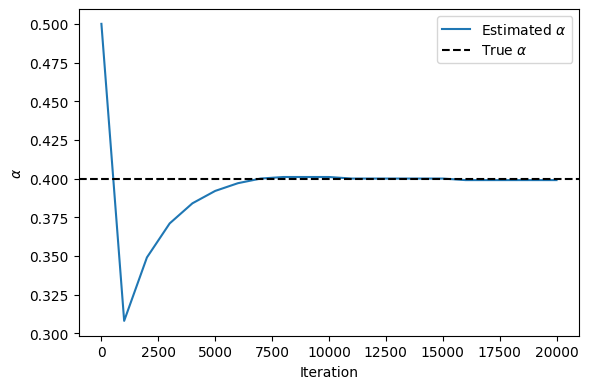

In [ ]:
import re

iterations, alpha_hist = [], []
with open("alpha_history.dat") as f:
    for line in f:
        nums = re.findall(r"[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?", line)
        iterations.append(int(float(nums[0])))
        alpha_hist.append(float(nums[1]))

iterations = np.array(iterations)
alpha_hist = np.array(alpha_hist)

plt.figure(figsize=(6, 4))
plt.plot(iterations, alpha_hist, label=r"Estimated $\alpha$")
plt.axhline(alpha_true, color="k", linestyle="--", label=r"True $\alpha$")
plt.xlabel("Iteration")
plt.ylabel(r"$\alpha$")
plt.legend()
plt.tight_layout()
plt.show()

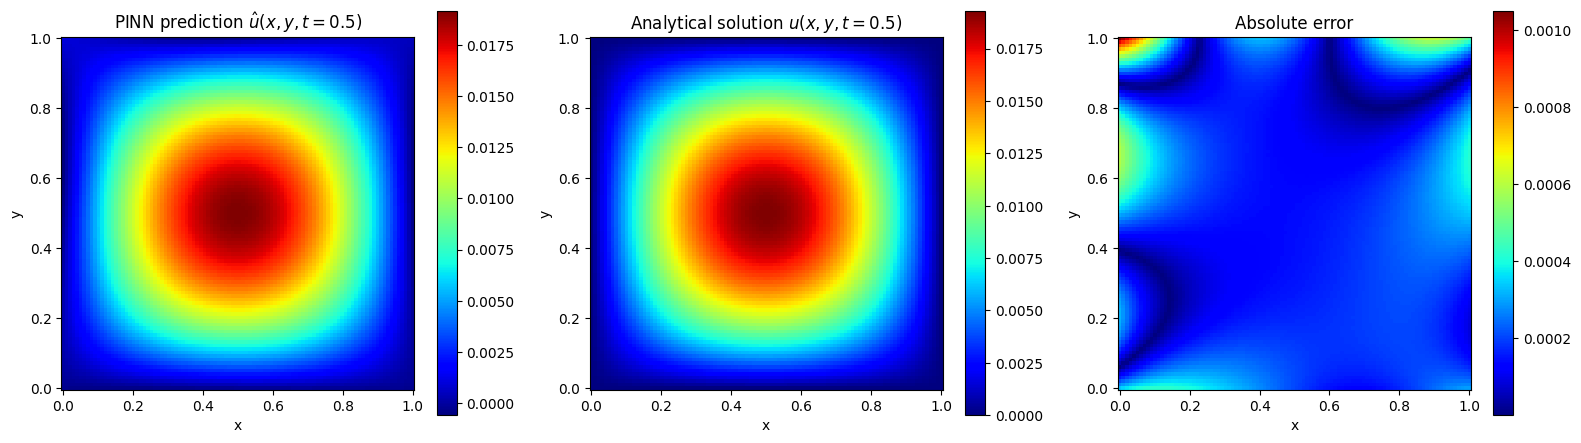

In [ ]:
nx, ny = 100, 100
x = np.linspace(0, 1, nx)
y = np.linspace(0, 1, ny)
X, Y = np.meshgrid(x, y)
t_fixed = 0.5 * np.ones((nx * ny, 1))
XYT = np.hstack((X.reshape(-1, 1), Y.reshape(-1, 1), t_fixed))

u_pred = model.predict(XYT).reshape(ny, nx)
u_true = u_exact(XYT).reshape(ny, nx)
error = np.abs(u_pred - u_true)

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axs[0].pcolormesh(X, Y, u_pred, shading="auto", cmap="jet")
axs[0].set_title(r"PINN prediction $\hat{u}(x,y,t{=}0.5)$")
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].pcolormesh(X, Y, u_true, shading="auto", cmap="jet")
axs[1].set_title(r"Analytical solution $u(x,y,t{=}0.5)$")
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].pcolormesh(X, Y, error, shading="auto", cmap="jet")
axs[2].set_title("Absolute error")
fig.colorbar(im2, ax=axs[2])

for ax in axs:
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

### Exercises

1. Consider the problem in the above example and its walkthrough implementation.

   a. In the forward problem, only $\boldsymbol{\theta}$ is updated based on the gradient. Here, $\alpha$ is included in the `pde(x,u)` and passed to `model.compile` as an external trainable variable.

      Explain, in terms of automatic differentiation and the chain rule, how a gradient with respect to $\alpha$ arises from the loss term $\mathrm{MSE}_{\mathrm{observed}}$, knowing that it does not mention $\alpha$ itself.



In [ ]:
# Write your code here

b. Consider that the observed data `observe_bc` is removed from the list passed to `dde.data.TimePDE`, leaving only the PDE residual and the boundary/initial conditions.

   ii. Retrain the model in this configuration and analyse if $\alpha$ converges to $\alpha_{\mathrm{true}}$.

   ii. Explain why, without any observed measurements of $u$, the trivial solution $\hat{u} \equiv 0$ can satisfy the PDE residual and the given boundary/initial conditions for any value of $\alpha$, and relate this to the general notion of parameter identifiability in inverse problems.




In [ ]:
# Write your code here

c. Change the initial guess of the unknown parameter to:

```python
alpha = dde.Variable(-0.5)
```

i. Retrain the model and analyse if the optimiser is still able to recover $\alpha_{\mathrm{true}}$.

ii. Physically, what does a negative diffusivity correspond to in the heat equation?

iii. Explain why a gradient-based optimiser might struggle to escape a poor initial guess in this problem, knowing that the loss landscape for $\boldsymbol{\theta}$ alone is well-behaved.

In [ ]:
# Write your code here

2. Let us now study the effect of the observed data ${(t_n,x_n,y_n,u_n)}*{n=1}^{N*{\mathrm{observed}}}$ on the convergence of $\alpha$ in Fig. $\ref{fig:alphaConvergenceInverseWalkthough}$.

   a. Reduce `N_observed` from 200 to 20 points. Retrain the model and regenerate the $\alpha$-convergence plot. Does $\alpha$ still converge to $\alpha_{\mathrm{true}}$, and if so, does it converge as quickly and as smoothly as with `N_observed = 200`? At what point, if any, would you expect further reducing `N_observed` to make the estimate unreliable?

   b. Real sensor or experimental measurements are never exact. Corrupt the synthetic observations with Gaussian noise:

```python id="j0bqf1"
noise_std = 0.02
observe_u_noisy = observe_u + np.random.normal(0, noise_std, observe_u.shape)
observe_bc = dde.icbc.PointSetBC(observe_x, observe_u_noisy, component=0)
```


  Retrain the model with the noisy data and compare the final estimate of $\alpha$ to $\alpha_{\mathrm{true}}$.

  i. Is the resulting estimate biased, or does it scatter around the true value?

  ii. What role does the PDE residual play in preventing the network from overfitting the noise in $\mathrm{MSE}_{\mathrm{observed}}$?




In [ ]:
# Write your code here

c. So far, we have never talked about the penalty parameters $\boldsymbol{\mu}$. By default, DeepXDE uses $\boldsymbol{\mu}=1$; however, `model.compile` accepts a `loss_weights` argument so that each term of the loss (in the listed order, followed by the PDE term) can be weighted independently using a fixed value:

```python id="r3yq1a"
model.compile(
    "adam",
    lr=1e-3,
    external_trainable_variables=[alpha],
    loss_weights=[1, 1, 100, 1],  # [bc, ic, observed, PDE]
)
```


  Retrain the model with the observed-data term weighted 100 times more heavily than the others and using the noisy data from (b).

  i. Does this change how quickly $\alpha$ converges or its final value?

  ii. Explain the role of the penalty parameters $\boldsymbol{\mu}$ in the trade-off between fitting the observed data closely and satisfying the PDE residual.



In [ ]:
# Write your code here